# RoBERTa — full (unbalanced) training set + class-weighted loss

Trains on the full training split (`train_data.csv`, ~16k rows, imbalanced) and handles imbalance via weighted cross-entropy.

Pairs with `RoBERTa_balanced.ipynb`, which trains on the *same* split after downsampling to equal class counts and uses plain cross-entropy. The only intentional difference between the two notebooks is **balanced-via-downsampling** vs. **unbalanced-with-class-weights**; everything else (tokenizer, model, training args, seed, early stopping, metrics) is held constant so the comparison is clean.

In [7]:
import numpy as np
import pandas as pd
import torch
from transformers import RobertaTokenizer, RobertaForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

In [8]:
# 1. Use GPU
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [9]:
# Load the pre-existing deduplicated splits
train_df = pd.read_csv('../data/train_data.csv').dropna(subset=['content', 'Sentiment'])
test_df = pd.read_csv('../data/test_data.csv').dropna(subset=['content', 'Sentiment'])

# Carve a validation set out of the training split
train_df, val_df = train_test_split(train_df, test_size=0.125, random_state=42, stratify=train_df['Sentiment'])

# NO balancing — we keep the natural class distribution and handle it via class weights below.
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print("Train counts (unbalanced):", train_df['Sentiment'].value_counts().to_dict())

Train: 14365 | Val: 2053 | Test: 4105
Train counts (unbalanced): {'Negative': 5729, 'Neutral': 4520, 'Positive': 4116}


In [10]:
# Sanity checks to prevent leakage / silent data issues

def _make_keys(df):
    return set(zip(df['appName'].astype(str), df['content'].astype(str)))

for name, df_ in [('train', train_df), ('val', val_df), ('test', test_df)]:
    assert df_[['appName', 'content', 'clean_content', 'Sentiment']].isna().any(axis=1).sum() == 0, f"Missing core fields in {name}"
    assert (df_['content'].astype(str).str.strip() == '').sum() == 0, f"Empty content in {name}"

train_keys = _make_keys(train_df)
val_keys = _make_keys(val_df)
test_keys = _make_keys(test_df)

assert len(train_keys & val_keys) == 0, "Train/Val overlap detected"
assert len(train_keys & test_keys) == 0, "Train/Test overlap detected"
assert len(val_keys & test_keys) == 0, "Val/Test overlap detected"

print("Sanity checks passed")
print(f"Train rows: {len(train_df)} | Val rows: {len(val_df)} | Test rows: {len(test_df)}")
print("Train label counts:", train_df['Sentiment'].value_counts().to_dict())
print("Val label counts:", val_df['Sentiment'].value_counts().to_dict())
print("Test label counts:", test_df['Sentiment'].value_counts().to_dict())

Sanity checks passed
Train rows: 14365 | Val rows: 2053 | Test rows: 4105
Train label counts: {'Negative': 5729, 'Neutral': 4520, 'Positive': 4116}
Val label counts: {'Negative': 819, 'Neutral': 646, 'Positive': 588}
Test label counts: {'Negative': 1637, 'Neutral': 1292, 'Positive': 1176}


In [11]:
# Convert text labels (Positive/Negative/Neutral) to numbers (0, 1, 2)
le = LabelEncoder()
train_labels = le.fit_transform(train_df['Sentiment'])
val_labels = le.transform(val_df['Sentiment'])
test_labels = le.transform(test_df['Sentiment'])

# Balanced class weights from the *unbalanced* training labels.
# Formula: w_c = n_samples / (n_classes * n_samples_in_c) — rarer classes get larger weights.
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(le.classes_)),
    y=train_labels,
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print('Class weights:', dict(zip(le.classes_, class_weights.cpu().numpy().round(3))))

Class weights: {'Negative': np.float32(0.836), 'Neutral': np.float32(1.059), 'Positive': np.float32(1.163)}


In [12]:
# Load the RoBERTa Tokenizer
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

In [13]:
# Tokenize raw text with fixed-length padding so train/val/test tensors match shape.
train_encodings = tokenizer(train_df['content'].tolist(), truncation=True, padding='max_length', max_length=128)
val_encodings   = tokenizer(val_df['content'].tolist(),   truncation=True, padding='max_length', max_length=128)
test_encodings  = tokenizer(test_df['content'].tolist(),  truncation=True, padding='max_length', max_length=128)

In [14]:
# Create a Custom PyTorch Dataset
class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_dataset = ReviewDataset(train_encodings, train_labels)
val_dataset = ReviewDataset(val_encodings, val_labels)
test_dataset = ReviewDataset(test_encodings, test_labels)

In [15]:
# Load the pre-trained RoBERTa model (configured for 3 labels)
model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=3)
model.to(device)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [16]:
# Define the evaluation metrics (same as balanced notebook)
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    f1 = f1_score(labels, preds, average='macro')
    precision = precision_score(labels, preds, average='macro')
    recall = recall_score(labels, preds, average='macro')
    return {'macro_f1': f1, 'macro_precision': precision, 'macro_recall': recall}

In [17]:
# Custom Trainer that applies weighted cross-entropy.
# Class weights are passed explicitly via __init__ so the trainer doesn't
# rely on a closure over a module-global.
class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


# warmup_steps computed explicitly from the training set size (same recipe as balanced)
batch_size = 16
num_epochs = 10
steps_per_epoch = -(-len(train_dataset) // batch_size)  # ceiling division
total_steps = steps_per_epoch * num_epochs
warmup_steps = int(0.1 * total_steps)
print(f'Training steps: {total_steps} (warmup: {warmup_steps})')

training_args = TrainingArguments(
    output_dir='./results_full',
    num_train_epochs=num_epochs,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=warmup_steps,
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,
    save_total_limit=2,
    report_to='none',
    seed=42,
)

trainer = WeightedTrainer(
    class_weights=class_weights,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Starting Training...")
trainer.train()

Training steps: 8980 (warmup: 898)
Starting Training...


/Users/jakobaune/anaconda3/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Macro F1,Macro Precision,Macro Recall
1,0.956977,0.844100,0.632227,0.663410,0.654793
2,0.744131,0.756906,0.654920,0.661371,0.665786
3,0.657131,0.836822,0.651039,0.666480,0.668536
4,0.569822,0.859288,0.663935,0.666666,0.674066
5,0.496470,0.909216,0.645182,0.646851,0.650808
6,0.409666,1.041568,0.635038,0.639427,0.646492


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/jakobaune/anaconda3/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/jakobaune/anaconda3/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=5388, training_loss=0.6280727882073734, metrics={'train_runtime': 2944.3155, 'train_samples_per_second': 48.789, 'train_steps_per_second': 3.05, 'total_flos': 5669436368494080.0, 'train_loss': 0.6280727882073734, 'epoch': 6.0})

/Users/jakobaune/anaconda3/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)



--- FINAL ROBERTA RESULTS (full + class-weighted) ---


Macro F1-score: 0.6592
Macro Precision: 0.6631
Macro Recall: 0.6715

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.77      0.76      1637
     Neutral       0.60      0.43      0.50      1292
    Positive       0.64      0.81      0.72      1176

    accuracy                           0.68      4105
   macro avg       0.66      0.67      0.66      4105
weighted avg       0.67      0.68      0.67      4105



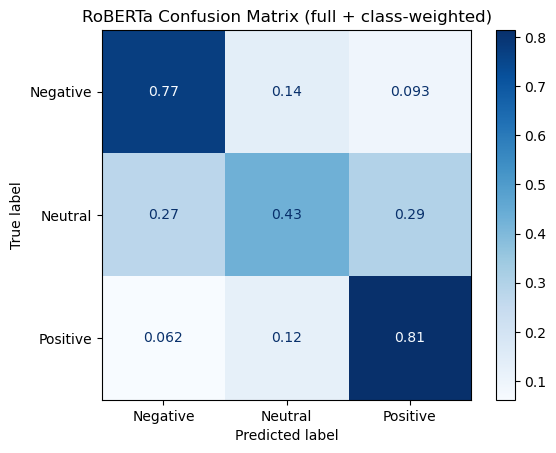

ChatGPT Macro F1: 0.6287
Claude Macro F1: 0.7401
Gemini Macro F1: 0.6378


In [18]:
# Evaluation on the Test Set

print("\n--- FINAL ROBERTA RESULTS (full + class-weighted) ---")
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

macro_f1 = f1_score(labels, preds, average='macro')
macro_precision = precision_score(labels, preds, average='macro')
macro_recall = recall_score(labels, preds, average='macro')

print(f"Macro F1-score: {macro_f1:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall: {macro_recall:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(labels, preds, target_names=le.classes_))

ConfusionMatrixDisplay.from_predictions(labels, preds, display_labels=le.classes_, cmap='Blues', normalize='true')
plt.title('RoBERTa Confusion Matrix (full + class-weighted)')
plt.show()

# Per-app F1 breakdown
test_df = test_df.copy()
test_df['prediction'] = le.inverse_transform(preds)
for app in sorted(test_df['appName'].unique()):
    sub = test_df[test_df['appName'] == app]
    f1_app = f1_score(sub['Sentiment'], sub['prediction'], average='macro')
    print(f"{app} Macro F1: {f1_app:.4f}")